Verify that the implementation of the qDRIFT subroutine is correct. 
Compute error statistics for the qDRIFT subroutine.

In [1]:
import sys, os
import numpy as np
from qiskit.quantum_info import Pauli, SparsePauliOp, Operator
from qiskit_aer import AerSimulator  # as of 25Mar2025
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit

# add ../..
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from src.utils.generate_hamiltonians import create_h2_minimal_basis_hamiltonian, generate_ising_hamiltonian

In [2]:
# H2 Hamiltonian in minimal basis
H2_HAMILTONIAN = create_h2_minimal_basis_hamiltonian()
alpha_h2 = np.sum(np.abs(H2_HAMILTONIAN.coeffs))
ISING_HAMILTONIAN = generate_ising_hamiltonian(num_qubits=4, J=1.0, g=1.0)
N = 1000000

Let $$V_{\vec{j}} = \prod_{k=1}^N e^{i \tau H_{\vec{j}_k}}$$ be the approximate evolution operator obtained from the qDRIFT algorithm, where $\vec{j}$ is a vector of $N$ indices sampled from the probability distribution $p_j = \frac{|h_j|}{\sum_k |h_k|}$, and $\tau = \frac{\lambda t}{N}$ with $\lambda = \sum_k |h_k|$. The true evolution operator is given by $U(t) = e^{iHt}$.

Lets compute 
$$

tr\left(  O V_{\vec{j}} \rho V_{\vec{j}}^\dagger \right) - tr\left( O U(t) \rho U(t)^\dagger \right)

$$ for a given initial state $\rho$ and average over many random samples of $\vec{j}$ to estimate the expected error of the qDRIFT approximation.

And also the trace distance between the states:
$$\frac{1}{2} \| V_{\vec{j}} \rho V_{\vec{j}}^\dagger - U(t) \rho U(t)^\dagger \|_1$$


In [3]:
# qdrift
def qdrift(hamiltonian: SparsePauliOp, time: float, n_qdrift_segments: int) -> QuantumCircuit:
    """
    Return ONE qDRIFT circuit whose unitary approximates e^{-iHt}.

    Args:
        hamiltonian: Hamiltonian as a SparsePauliOp.
        time: Total evolution time.
        n_qdrift_segments: Number of qDRIFT segments.
    Returns:
        A QuantumCircuit implementing the qDRIFT approximation.
    """
    alpha = np.sum(np.abs(hamiltonian.coeffs))
    pmf = np.abs(hamiltonian.coeffs) / alpha
    n_qubits = hamiltonian.num_qubits
    qc = QuantumCircuit(n_qubits)
    tau = (alpha * time) / n_qdrift_segments

    for _ in range(n_qdrift_segments):
        chosen_index = np.random.choice(len(hamiltonian.paulis), p=pmf)
        chosen_pauli = hamiltonian.paulis[chosen_index]
        chosen_coeff = hamiltonian.coeffs[chosen_index]
        H_j = chosen_pauli if chosen_coeff > 0 else -chosen_pauli

        U_j = PauliEvolutionGate(H_j, time=tau)
        qc.append(U_j, range(n_qubits))
    return qc

def circuit_to_unitary(circuit: QuantumCircuit) -> np.ndarray:
    """Return the unitary matrix of a QuantumCircuit as a numpy array."""
    return Operator(circuit).data

def trace_norm_distance(U: np.ndarray, V: np.ndarray) -> float:
    """Compute the trace norm distance ||U - V||_1."""
    diff = U - V
    s = np.linalg.svd(diff, compute_uv=False)
    return np.sum(s)

def observable_expectation_diff(O: np.ndarray, rho: np.ndarray, U: np.ndarray, V: np.ndarray) -> float:
    """
    Compute tr(O V ρ V†) - tr(O U ρ U†).
    
    Args:
        O: Observable matrix (numpy array).
        rho: Density matrix (numpy array).
        U: Exact unitary.
        V: Approximate unitary.
    """
    evolved_rho_U = U @ rho @ U.conj().T
    evolved_rho_V = V @ rho @ V.conj().T
    return np.trace(O @ evolved_rho_V) - np.trace(O @ evolved_rho_U)


In [4]:
t_vals = np.logspace(base=10, start=-3, stop=0.5, num=100)  # Time values from 0.01 to 100
Vs = []
Us = []
for t in t_vals:
    qc_h2 = qdrift(H2_HAMILTONIAN, time=t, n_qdrift_segments=N)
    V_h2 = circuit_to_unitary(qc_h2)
    U_h2 = Operator(PauliEvolutionGate(H2_HAMILTONIAN, time=t)).data
    Vs.append(V_h2)
    Us.append(U_h2)


KeyboardInterrupt: 

In [ ]:
Vs_ising = []
Us_ising = []
for t in t_vals:
    qc_ising = qdrift(ISING_HAMILTONIAN, time=t, n_qdrift_segments=N)
    V_ising = circuit_to_unitary(qc_ising)
    U_ising = Operator(PauliEvolutionGate(ISING_HAMILTONIAN, time=t)).data
    Vs_ising.append(V_ising)
    Us_ising.append(U_ising)
    

In [ ]:
trace_norm_distances_h2 = [trace_norm_distance(U, V) for U, V in zip(Us, Vs)]
trace_norm_distances_ising = [trace_norm_distance(U, V) for U, V in zip(Us_ising, Vs_ising)]

C:\Users\rodcs\AppData\Local\Temp\ipykernel_28944\2372752920.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.loglog(t_vals, 2 *(t_vals**2) / N, 'k--', label='O(t^2/N) Bound', color='black')


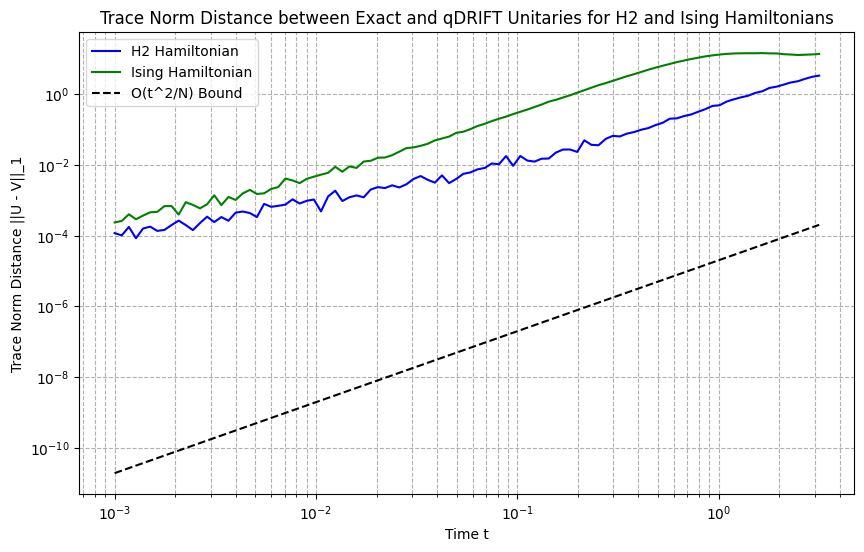

In [ ]:
import matplotlib.pyplot as plt
# plot trace norm distances for H2 and Ising
plt.figure(figsize=(10, 6))
plt.loglog(t_vals, trace_norm_distances_h2, label='H2 Hamiltonian', color='blue')
plt.loglog(t_vals, trace_norm_distances_ising, label='Ising Hamiltonian', color='green')
plt.loglog(t_vals, 2 *(t_vals**2) / N, 'k--', label='O(t^2/N) Bound', color='black')

plt.xlabel('Time t')    
plt.ylabel('Trace Norm Distance ||U - V||_1')
plt.legend()
plt.title('Trace Norm Distance between Exact and qDRIFT Unitaries for H2 and Ising Hamiltonians')
plt.grid(True, which="both", ls="--")
plt.show()

In [ ]:
# lets try to mesure observable expectation value differences: H, single-quits, multi-qubit, and projectors into computational basis states
observable_expectation_values_h2 = {
    'H': [],
    'single_qubit': [],
    'multi_qubit': [],
    'projector': []
}
H_matrix = H2_HAMILTONIAN.to_matrix()
n_qubits = H2_HAMILTONIAN.num_qubits
dim = 2**n_qubits
# H \otimes 1 
for t, U, V in zip(t_vals, Us, Vs):
    # Hamiltonian as observable
    diff_H = observable_expectation_diff(H_matrix, rho, U, V)
    observable_expectation_values_h2['H'].append(diff_H)


    

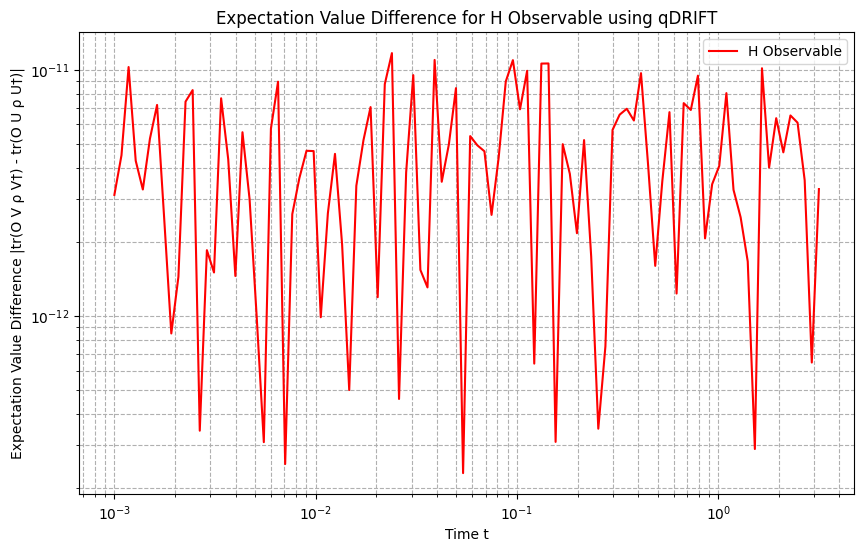

In [ ]:
plt.figure(figsize=(10, 6))
plt.loglog(t_vals, np.abs(observable_expectation_values_h2['H']), label='H Observable', color='red')
plt.xlabel('Time t')    
plt.ylabel('Expectation Value Difference |tr(O V ρ V†) - tr(O U ρ U†)|')
plt.legend()
plt.title('Expectation Value Difference for H Observable using qDRIFT')
plt.grid(True, which="both", ls="--")
plt.show()
